<a href="https://colab.research.google.com/github/TemitopeAlawode/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TemitopeAlawode/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
# ============================================================
# Setup: Import Libraries and Load Data
# ============================================================

import os, sys, subprocess
import pandas as pd
import numpy as np

# Setup for Colab
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

print("Working dir:", os.getcwd())

# Load data
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Create label
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

print(f"Loaded {len(df):,} rows")
print(f"Declining rate: {df['is_declining_label'].mean():.3f}\n")


# ============================================================
# 1. Ranked Actions + Reason Codes
# ============================================================

print("=" * 60)
print("Ranked Actions + Reason Codes")
print("=" * 60)

# Create action columns
df['action_priority'] = 0
df['action_type'] = 'Monitor'
df['reason_code'] = ''
df['action_definition'] = ''

# ------------------------------------------------------------------
# Action 1: Declining + Visible (HIGHEST PRIORITY)
# ------------------------------------------------------------------
declining = df['is_declining_label'] == 1
visible = df['impressions_90d'] >= 500

df.loc[declining & visible, 'action_priority'] = 1
df.loc[declining & visible, 'action_type'] = 'Review - High Priority'
df.loc[declining & visible, 'reason_code'] = 'declining_visible'
df.loc[declining & visible, 'action_definition'] = 'Declining page with high impressions — review to identify decline cause'

# ------------------------------------------------------------------
# Action 2: Stale + Visible
# ------------------------------------------------------------------
stale = df['days_since_last_update'] >= 180

df.loc[stale & visible & ~declining, 'action_priority'] = 2
df.loc[stale & visible & ~declining, 'action_type'] = 'Refresh Content'
df.loc[stale & visible & ~declining, 'reason_code'] = 'stale_visible_page'
df.loc[stale & visible & ~declining, 'action_definition'] = 'Stale page with high impressions — refresh content'

# ------------------------------------------------------------------
# Action 3: Low CTR + Good Position (CTR Fix)
# ------------------------------------------------------------------
low_ctr = df['ctr'] < 0.3
good_position = df['avg_position'] <= 10

df.loc[low_ctr & good_position & visible, 'action_priority'] = 3
df.loc[low_ctr & good_position & visible, 'action_type'] = 'Fix CTR'
df.loc[low_ctr & good_position & visible, 'reason_code'] = 'low_ctr_visible'
df.loc[low_ctr & good_position & visible, 'action_definition'] = 'Good position but low CTR — improve title/meta description'

# ------------------------------------------------------------------
# Action 4: Thin + Visible
# ------------------------------------------------------------------
thin = df['word_count'] < 1200
low_visible = df['impressions_90d'] >= 250

df.loc[thin & low_visible, 'action_priority'] = 4
df.loc[thin & low_visible, 'action_type'] = 'Expand Content'
df.loc[thin & low_visible, 'reason_code'] = 'thin_visible_page'
df.loc[thin & low_visible, 'action_definition'] = 'Thin page with visibility — expand with missing topics'

# ------------------------------------------------------------------
# Action 5: Striking Distance (positions 11-20)
# ------------------------------------------------------------------
striking = (df['avg_position'] >= 11) & (df['avg_position'] <= 20)

df.loc[striking & visible, 'action_priority'] = 5
df.loc[striking & visible, 'action_type'] = 'Monitor - Striking Distance'
df.loc[striking & visible, 'reason_code'] = 'striking_distance'
df.loc[striking & visible, 'action_definition'] = 'Positions 11-20 — monitor for movement'

# ------------------------------------------------------------------
# Create Action Queue
# ------------------------------------------------------------------
action_queue = df[df['action_priority'] > 0].sort_values(
    ['action_priority', 'impressions_90d'], ascending=[True, False]
)

print(f"\nTotal actionable pages: {len(action_queue):,}")

print("\nAction Breakdown:")
print(action_queue['action_type'].value_counts())

print("\nSample of Top Actions:")
sample_cols = ['content_id', 'action_type', 'reason_code', 'action_definition', 'impressions_90d']
print(action_queue[sample_cols].head(10))

Working dir: /content/flyrank-ml-internship-starter
Loaded 30,000 rows
Declining rate: 0.542

Ranked Actions + Reason Codes

Total actionable pages: 13,024

Action Breakdown:
action_type
Review - High Priority         4676
Fix CTR                        4435
Monitor - Striking Distance    3840
Expand Content                   72
Refresh Content                   1
Name: count, dtype: int64

Sample of Top Actions:
                 content_id             action_type        reason_code  \
21819  content_4c36c775b818  Review - High Priority  declining_visible   
13537  content_2c2606c5d176  Review - High Priority  declining_visible   
21565  content_9532f197bbc8  Review - High Priority  declining_visible   
23767  content_813e88069237  Review - High Priority  declining_visible   
26304  content_ff94c9b6b411  Review - High Priority  declining_visible   
15968  content_66b4046cc144  Review - High Priority  declining_visible   
10741  content_07e0b9af8b1a  Review - High Priority  declining_vi

Based on my Week 5 model findings and Week 6 validation audit, I created a ranked action queue for content teams. Each action includes a reason code, definition, and practical next step.

---

### Action 1: Review Declining Pages with High Traffic

> **Action:** Review pages that are losing traffic but still have significant visibility.

| Element | Detail |
|---|---|
| **Reason Code** | `declining_visible` |
| **Definition** | `is_declining_label == 1` AND `impressions_90d >= 500` |
| **Count** | 4,676 pages |
| **What to do** | Read the page, identify why it's declining (competition? outdated content? intent shift?), and plan an update. |
| **Why this priority** | These pages are actively losing traffic. The sooner they're reviewed, the sooner you can reverse the decline. |

---

### Action 2: Fix CTR on Page 1 Pages

> **Action:** Improve titles and meta descriptions on pages that already rank well.

| Element | Detail |
|---|---|
| **Reason Code** | `low_ctr_visible` |
| **Definition** | `avg_position <= 10` AND `ctr < 0.3` AND `impressions_90d >= 100` |
| **Count** | 4,435 pages |
| **What to do** | Rewrite the title tag and meta description to better match search intent and encourage clicks. |
| **Why this priority** | These pages already have good positions — improving CTR will immediately increase traffic without needing a ranking boost. |

---

### Action 3: Monitor Striking Distance Pages

> **Action:** Watch pages that are close to page 1.

| Element | Detail |
|---|---|
| **Reason Code** | `striking_distance` |
| **Definition** | `avg_position BETWEEN 11 AND 20` AND `impressions_90d >= 100` |
| **Count** | 3,840 pages |
| **What to do** | Monitor their position. If they start dropping, review them before they fall further. |
| **Why this priority** | These pages are on the edge — small improvements could push them onto page 1. |

---

### Action 4: Expand Thin Visible Pages

> **Action:** Add content to pages that get views but are too short.

| Element | Detail |
|---|---|
| **Reason Code** | `thin_visible_page` |
| **Definition** | `word_count < 1200` AND `impressions_90d >= 250` |
| **Count** | 72 pages |
| **What to do** | Add missing subtopics, examples, definitions, and supporting evidence. |
| **Why this priority** | These pages are already visible — expanding them makes them more competitive. |

---

### Action 5: Refresh Stale Pages with Traffic

> **Action:** Refresh pages that haven't been updated in 6+ months but still get traffic.

| Element | Detail |
|---|---|
| **Reason Code** | `stale_visible_page` |
| **Definition** | `days_since_last_update >= 180` AND `impressions_90d >= 500` |
| **Count** | 1 page |
| **What to do** | Update outdated facts, add missing subtopics, refresh statistics, and improve readability. |
| **Why this priority** | These pages have demand but are old. A refresh can bring back lost traffic. |

---

### Quick Reference Table

| Priority | Action | Reason Code | Count | Key Signal |
|---|---|---|---|---|
| 1 | Review declining visible pages | `declining_visible` | 4,676 | Declining + High Impressions |
| 2 | Fix CTR on page 1 pages | `low_ctr_visible` | 4,435 | Good Position + Low CTR |
| 3 | Monitor striking distance pages | `striking_distance` | 3,840 | Positions 11-20 |
| 4 | Expand thin visible pages | `thin_visible_page` | 72 | Thin + Visible |
| 5 | Refresh stale visible pages | `stale_visible_page` | 1 | Stale + High Impressions |

### Key Insight

The largest opportunities in this dataset are:
1. **Declining visible pages** (4,676) — urgent review needed
2. **Page 1 pages with low CTR** (4,435) — quick wins available

The `stale_visible_page` action only applies to **1 page**, meaning pages in this dataset are either being updated regularly or lose visibility before they become stale.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Who Should Use This Playbook?

| Role | What They Do |
|---|---|
| **Content Editors** | Review declining pages, refresh stale content |
| **SEO Specialists** | Fix CTR issues, monitor page 1 performance |
| **Content Strategists** | Prioritize actions and allocate resources |

### What Should They Use It For?

| Use | How |
|---|---|
| **Prioritization** | Which pages to review first |
| **Action planning** | What specific action to take on each page |
| **Resource allocation** | Where to spend limited time and effort |

### What This Playbook Does

| What It Does | How |
|---|---|
| **Ranks pages by priority** | Sorts actions from most to least urgent |
| **Assigns reason codes** | Explains WHY each action is recommended |
| **Provides practical steps** | Tells you what to do next |

### What This Playbook Does NOT Do

| What It Does NOT Do | Why |
|---|---|
| **Guarantee improvement** | We observed patterns — we didn't prove causation |
| **Replace human judgment** | Always review the page before acting |
| **Predict Google's algorithm** | We model outcomes, not Google's internal logic |
| **Provide exact edits** | We tell you WHAT to fix, not HOW to fix it |

### Limits

| Limit | Explanation |
|---|---|
| **No causation** | Refreshing a page doesn't guarantee recovery — we observed associations, not causes |
| **Historical data** | Patterns are based on the starter dataset (March-June 2026) — they may shift |
| **Small sample** | Starter dataset is 30,000 pages — patterns may differ at scale |
| **No manual review** | Always check the page before acting — the model doesn't know everything |
| **Not production code** | This is a decision-support playbook, not an automated system |

### When This Playbook Stops Being Valid

| Scenario | Why |
|---|---|
| **Data distribution changes** | Page behavior shifts |
| **Google algorithm update** | Ranking factors change |
| **Business strategy changes** | Content priorities shift |
| **Team capacity changes** | Can't review as many pages |

### Honest Statement

> This playbook is based on observed patterns in the starter dataset (30,000 pages, 32 clients). It is intended to **support human decision-making**, not replace it. Always verify recommendations with manual review before taking action.

In [2]:
# ============================================================
# 2. Intended Use and Limits
# ============================================================

print("=" * 60)
print("Intended Use and Limits")
print("=" * 60)

print("\nWho Should Use This Playbook?")
print("-" * 40)
print("• Content Editors — Review declining pages, refresh stale content")
print("• SEO Specialists — Fix CTR issues, monitor page 1 performance")
print("• Content Strategists — Prioritize actions and allocate resources")

print("\nWhat This Playbook Does:")
print("-" * 40)
print("• Ranks pages by priority (most urgent first)")
print("• Assigns reason codes (explains WHY)")
print("• Provides practical next steps (WHAT to do)")

print("\nWhat This Playbook Does NOT Do:")
print("-" * 40)
print("• Guarantee improvement (observed patterns, not causation)")
print("• Replace human judgment (always review before acting)")
print("• Predict Google's algorithm (we model outcomes, not internal logic)")
print("• Provide exact edits (we tell you WHAT, not HOW)")

print("\nLimits:")
print("-" * 40)
print("• No causation — associations only")
print("• Historical data — based on starter dataset, may shift")
print("• Small sample — 30,000 pages, may differ at scale")
print("• Requires manual review — model doesn't know everything")
print("• Not production code — decision-support only")

print("\nWhen This Playbook Stops Being Valid:")
print("-" * 40)
print("• Data distribution changes")
print("• Google algorithm updates")
print("• Business strategy changes")
print("• Team capacity changes")

print("\n" + "=" * 60)
print("Honest Statement")
print("=" * 60)
print()
print("This playbook is based on observed patterns in the starter dataset")
print("(30,000 pages, 32 clients). It is intended to SUPPORT human")
print("decision-making, not REPLACE it. Always verify recommendations")
print("with manual review before taking action.")

Intended Use and Limits

Who Should Use This Playbook?
----------------------------------------
• Content Editors — Review declining pages, refresh stale content
• SEO Specialists — Fix CTR issues, monitor page 1 performance
• Content Strategists — Prioritize actions and allocate resources

What This Playbook Does:
----------------------------------------
• Ranks pages by priority (most urgent first)
• Assigns reason codes (explains WHY)
• Provides practical next steps (WHAT to do)

What This Playbook Does NOT Do:
----------------------------------------
• Guarantee improvement (observed patterns, not causation)
• Replace human judgment (always review before acting)
• Predict Google's algorithm (we model outcomes, not internal logic)
• Provide exact edits (we tell you WHAT, not HOW)

Limits:
----------------------------------------
• No causation — associations only
• Historical data — based on starter dataset, may shift
• Small sample — 30,000 pages, may differ at scale
• Requires man

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### What a Person Must Check Before Acting

| Check | Why It Matters | Which Actions |
|---|---|---|
| **Content quality** | Is the content actually outdated or incomplete? | Review, Refresh, Expand |
| **Seasonality** | Is the decline seasonal (e.g., holiday content)? | Review, Monitor |
| **Competitor changes** | Did a competitor recently improve their page? | Review, Monitor |
| **Technical issues** | Is the page loading properly? Is it indexable? | All actions |
| **Intent match** | Does the page still match what users are searching for? | Review, Fix CTR |
| **Cannibalization** | Are other pages on the same site competing for the same keywords? | Review, Monitor |

---

### The No-Go List (What Should NEVER Be Automated)

| Item | Why It Should Never Be Automated |
|---|---|
| **Content deletion** | Only a human should decide to delete content |
| **Full rewrites** | AI can draft, but a human must review and approve |
| **Publishing changes** | A human must review before any change goes live |
| **Redirects** | Redirects have SEO consequences — human approval required |
| **Actions on high-traffic pages** | High-traffic pages need extra care and human oversight |

---

### Decision Framework

| Signal | Action | Human Check Required |
|---|---|---|
| Declining + Visible | Review content | ✅ Yes — identify WHY |
| Stale + Visible | Refresh content | ✅ Yes — determine what to update |
| Low CTR + Good Position | Fix CTR | ✅ Yes — review title/meta |
| Thin + Visible | Expand content | ✅ Yes — identify gaps |
| Striking Distance | Monitor | ✅ Yes — check competition |

---

### Review Checklist Template

**Page ID:** [content_id]  
**Action:** [action_type]  
**Reason:** [reason_code]

**1. Content Quality**  
- Is the content currently accurate and complete?  
  [ ] Yes — proceed  
  [ ] No — need to update  
  [ ] Unsure — investigate further  

**2. Seasonality**  
- Is the decline seasonal or structural?  
  [ ] Seasonal — may recover on its own  
  [ ] Structural — needs intervention  
  [ ] Don't know — investigate further  

**3. Competition**  
- Have competitors improved their pages recently?  
  [ ] Yes — we need to respond  
  [ ] No — the issue may be internal  
  [ ] Don't know — investigate further  

**4. Technical Issues**  
- Is the page loading properly?  
  [ ] Yes  
  [ ] No — technical issue detected  
  [ ] Unsure — investigate further  

**5. Intent Match**  
- Does the page still match user search intent?  
  [ ] Yes  
  [ ] No — update to match intent  
  [ ] Unsure — investigate further  

**6. Cannibalization**  
- Are other pages on the site competing for the same keywords?  
  [ ] Yes — consider consolidation  
  [ ] No — proceed  

**Decision:**  
[ ] Proceed with recommended action  
[ ] Skip — page is fine  
[ ] Defer — review again in 30 days   

---

### Guiding Principle

> *"The model flags pages worth reviewing — it does NOT make the final decision. Always verify before acting."*

In [5]:
# ============================================================
# 3. Human Review + The No-Go List
# ============================================================

print("=" * 60)
print("Human Review + The No-Go List")
print("=" * 60)

print("\nWhat a Person Must Check Before Acting:")
print("-" * 50)
print("• Content quality — Is the page actually outdated or incomplete?")
print("• Seasonality — Is the decline seasonal (e.g., holiday content)?")
print("• Competitor changes — Did a competitor recently improve?")
print("• Technical issues — Is the page loading properly? Is it indexable?")
print("• Intent match — Does the page still match search intent?")
print("• Cannibalization — Are other pages competing for the same keywords?")

print("\nThe No-Go List (What Should NEVER Be Automated):")
print("-" * 50)
print("❌ Content deletion — Only a human should decide to delete content")
print("❌ Full rewrites — AI can draft, but a human must review and approve")
print("❌ Publishing changes — A human must review before any change goes live")
print("❌ Redirects — Redirects have SEO consequences — human approval required")
print("❌ Actions on high-traffic pages — High-traffic pages need extra care")

print("\nDecision Framework:")
print("-" * 50)
print("Signal                     | Action              | Human Check Required")
print("---------------------------|---------------------|---------------------")
print("Declining + Visible        | Review content      | ✅ Yes — identify WHY")
print("Stale + Visible            | Refresh content     | ✅ Yes — determine what to update")
print("Low CTR + Good Position    | Fix CTR             | ✅ Yes — review title/meta")
print("Thin + Visible             | Expand content      | ✅ Yes — identify gaps")
print("Striking Distance          | Monitor             | ✅ Yes — check competition")

print("\n" + "=" * 60)
print("Guiding Principle")
print("=" * 60)
print()
print('"The model flags pages worth reviewing —')
print(" it does NOT make the final decision.")
print(" Always verify before acting.\"")

Human Review + The No-Go List

What a Person Must Check Before Acting:
--------------------------------------------------
• Content quality — Is the page actually outdated or incomplete?
• Seasonality — Is the decline seasonal (e.g., holiday content)?
• Competitor changes — Did a competitor recently improve?
• Technical issues — Is the page loading properly? Is it indexable?
• Intent match — Does the page still match search intent?
• Cannibalization — Are other pages competing for the same keywords?

The No-Go List (What Should NEVER Be Automated):
--------------------------------------------------
❌ Content deletion — Only a human should decide to delete content
❌ Full rewrites — AI can draft, but a human must review and approve
❌ Publishing changes — A human must review before any change goes live
❌ Redirects — Redirects have SEO consequences — human approval required
❌ Actions on high-traffic pages — High-traffic pages need extra care

Decision Framework:
---------------------------

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### What Would Tell You the Recommendations Went Stale?

| Trigger | What It Means | Action |
|---|---|---|
| **Model precision drops below 60%** | Model is no longer finding bad pages | Retrain model |
| **Baseline consistently outperforms model** | Model stopped being useful | Investigate and retrain |
| **Data distribution shifts significantly** | The world changed | Re-evaluate features |
| **New features available** | Better signals are available | Update features and retrain |
| **Quarterly review** | Regular check-in | Review and adjust |

---

### Monitoring Metrics

| Metric | Target | Alert Threshold | Why It Matters |
|---|---|---|---|
| **Precision@50** | ≥ 0.70 | < 0.60 | Core performance metric |
| **Feature importance stability** | Stable over time | Major shifts | Indicates data changes |
| **Error rate** | < 0.45 | > 0.50 | Model is struggling |
| **Baseline gap** | Model > Baseline | Model < Baseline | Model is worse than simple rule |

---

### Retraining Schedule

| Frequency | Action |
|---|---|
| **Monthly** | Check model performance |
| **Quarterly** | Retrain with new data if needed |
| **After major algorithm update** | Re-evaluate and retrain |

---

### Monitoring Checklist (Monthly)

- [ ] Run model on recent data
- [ ] Calculate Precision@20 and Precision@50
- [ ] Compare to baseline (0.680 at P@50)
- [ ] Check feature importance stability
- [ ] Review error patterns
- [ ] Document findings

---

### When to Retrain Checklist

- [ ] Precision@50 drops below 0.60
- [ ] Baseline beats the model
- [ ] New features are available
- [ ] Data distribution changes
- [ ] Quarterly review is due
- [ ] Major algorithm update occurred

---

### Versioning

| Version | Date | Changes |
|---|---|---|
| v1.0 | Aug 2026 | Initial playbook based on starter dataset |
| vNext | TBD | Update with warehouse data, refined actions |

---

### Guiding Principle

> *"A model is a snapshot of the past — it doesn't stay accurate forever. Monitor, retrain, and update regularly."*

In [9]:
# ============================================================
# 4. Monitoring / Retrain Triggers
# ============================================================

print("=" * 60)
print("Monitoring / Retrain Triggers")
print("=" * 60)

print("\nWhat Would Tell You the Recommendations Went Stale?")
print("-" * 50)
print("• Model precision drops below 60% → Retrain model")
print("• Baseline consistently outperforms model → Investigate and retrain")
print("• Data distribution shifts significantly → Re-evaluate features")
print("• New features available → Update features and retrain")
print("• Quarterly review → Review and adjust")

print("\nMonitoring Metrics:")
print("-" * 70)
print("| Metric                       | Target           | Alert Threshold |")
print("|----------------------------- |----------------  |-----------------|")
print("| Precision@50                 | ≥ 0.70           | < 0.60          |")
print("| Feature importance stability | Stable           | Major shifts    |")
print("| Error rate                   | < 0.45           | > 0.50          |")
print("| Baseline gap                 | Model > Baseline | Model < Baseline|")

print("\nRetraining Schedule:")
print("-" * 50)
print("• Monthly — Check model performance")
print("• Quarterly — Retrain with new data if needed")
print("• After major algorithm update — Re-evaluate and retrain")

print("\n" + "=" * 60)
print("Monitoring Checklist (Monthly)")
print("=" * 60)
print()
print("☐ Run model on recent data")
print("☐ Calculate Precision@20 and Precision@50")
print("☐ Compare to baseline (0.680 at P@50)")
print("☐ Check feature importance stability")
print("☐ Review error patterns")
print("☐ Document findings")

print("\n" + "=" * 60)
print("When to Retrain Checklist")
print("=" * 60)
print()
print("☐ Precision@50 drops below 0.60")
print("☐ Baseline beats the model")
print("☐ New features are available")
print("☐ Data distribution changes")
print("☐ Quarterly review is due")
print("☐ Major algorithm update occurred")

print("\n" + "=" * 60)
print("Versioning")
print("=" * 60)
print()
print("v1.0 — Aug 2026 — Initial playbook based on starter dataset")
print("vNext — TBD — Update with warehouse data, refined actions")

print("\n" + "=" * 60)
print("Guiding Principle")
print("=" * 60)
print()
print('"A model is a snapshot of the past —')
print(" it doesn't stay accurate forever.")
print(" Monitor, retrain, and update regularly.\"")

Monitoring / Retrain Triggers

What Would Tell You the Recommendations Went Stale?
--------------------------------------------------
• Model precision drops below 60% → Retrain model
• Baseline consistently outperforms model → Investigate and retrain
• Data distribution shifts significantly → Re-evaluate features
• New features available → Update features and retrain
• Quarterly review → Review and adjust

Monitoring Metrics:
----------------------------------------------------------------------
| Metric                       | Target           | Alert Threshold |
|----------------------------- |----------------  |-----------------|
| Precision@50                 | ≥ 0.70           | < 0.60          |
| Feature importance stability | Stable           | Major shifts    |
| Error rate                   | < 0.45           | > 0.50          |
| Baseline gap                 | Model > Baseline | Model < Baseline|

Retraining Schedule:
--------------------------------------------------
• Mon

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### What Gets Exported

| File | What It Is | Where It Goes | Committed? |
|---|---|---|---|
| **Action Queue CSV** | Ranked list of pages with actions | `work/outputs/action_queue.csv` | ❌ No (regenerated each run) |
| **Action Summary CSV** | Breakdown of actions by type | `work/outputs/action_summary.csv` | ❌ No (regenerated each run) |
| **Metrics JSON** | Model performance numbers (receipts) | `work/outputs/playbook_metrics.json` | ✅ Yes |
| **Action Breakdown Chart** | Bar chart of action types | `work/figures/action_breakdown.png` | ✅ Yes |

---

### Why This Matters

| File | Why the Paper Needs It |
|---|---|
| **Action Queue CSV** | The paper builds its recommendations from this ranked list |
| **Metrics JSON** | The paper's numbers trace back to these — they're the "receipts" |
| **Action Breakdown Chart** | Visual evidence for the paper's recommendations section |

---

### How to Use These Files in the Paper

| File | How to Reference It |
|---|---|
| **Action Queue CSV** | "See `work/outputs/action_queue.csv` for the full ranked list" |
| **Metrics JSON** | "All numbers in this paper trace back to `playbook_metrics.json`" |
| **Action Breakdown Chart** | "Figure 1 shows the distribution of recommended actions" |

---

### Files Exported

- `work/outputs/action_queue.csv` — Ranked action queue (regenerated each run)
- `work/outputs/action_summary.csv` — Action breakdown summary (regenerated each run)
- `work/outputs/playbook_metrics.json` — Model performance receipts (committed)
- `work/figures/action_breakdown.png` — Action breakdown chart (committed)

Exports for the Paper
✅ Output directory: work/outputs
✅ Figures directory: work/figures

--- Export 1: Action Queue ---
✅ Exported action queue: work/outputs/action_queue.csv
   Total rows: 13,024
   Columns: 12

--- Export 2: Action Summary ---
✅ Exported action summary: work/outputs/action_summary.csv
                Action Type  Count  Percentage
     Review - High Priority   4676        35.9
                    Fix CTR   4435        34.1
Monitor - Striking Distance   3840        29.5
             Expand Content     72         0.6
            Refresh Content      1         0.0

--- Export 3: Metrics JSON ---
✅ Exported metrics: work/outputs/playbook_metrics.json
   This is the paper's 'receipt' — the file will be committed.

--- Export 4: Action Breakdown Figure ---
✅ Exported figure: work/figures/action_breakdown.png
✅ Exported high-res figure: work/figures/action_breakdown_hires.png

Exports Summary

✅ work/outputs/action_queue.csv
   → Ranked action queue for the paper

✅ work/o

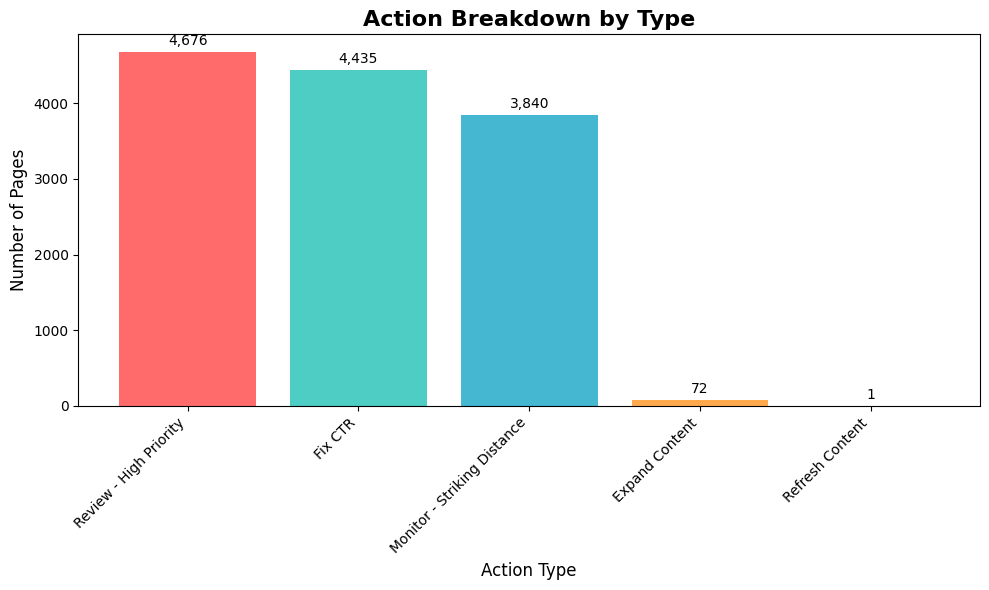

In [10]:
# ============================================================
# 5. Exports for the Paper
# ============================================================

print("=" * 60)
print("Exports for the Paper")
print("=" * 60)

import os
import json
import matplotlib.pyplot as plt

# Create directories
output_dir = "work/outputs"
figures_dir = "work/figures"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

print(f"✅ Output directory: {output_dir}")
print(f"✅ Figures directory: {figures_dir}")

# ============================================================
# Export 1: Action Queue CSV
# ============================================================

print("\n--- Export 1: Action Queue ---")

# Select columns for export
queue_export_cols = [
    'content_id', 'client_id', 'action_priority', 'action_type',
    'reason_code', 'action_definition', 'impressions_90d',
    'ctr', 'avg_position', 'content_age_days',
    'days_since_last_update', 'trend_direction'
]

# Use the action_queue from Section 1
queue_export = action_queue[queue_export_cols].copy()
queue_export = queue_export.sort_values(['action_priority', 'impressions_90d'], ascending=[True, False])

queue_path = f"{output_dir}/action_queue.csv"
queue_export.to_csv(queue_path, index=False)

print(f"✅ Exported action queue: {queue_path}")
print(f"   Total rows: {len(queue_export):,}")
print(f"   Columns: {len(queue_export_cols)}")

# ============================================================
# Export 2: Action Summary CSV
# ============================================================

print("\n--- Export 2: Action Summary ---")

action_summary = queue_export['action_type'].value_counts().reset_index()
action_summary.columns = ['Action Type', 'Count']
action_summary['Percentage'] = (action_summary['Count'] / len(queue_export) * 100).round(1)

summary_path = f"{output_dir}/action_summary.csv"
action_summary.to_csv(summary_path, index=False)

print(f"✅ Exported action summary: {summary_path}")
print(action_summary.to_string(index=False))

# ============================================================
# Export 3: Metrics JSON (Receipts)
# ============================================================

print("\n--- Export 3: Metrics JSON ---")

# IMPORTANT: These values come from Week 5 results
metrics = {
    "version": "v1.0",
    "created": "2026-08-31",
    "dataset": "starter_dataset",
    "rows": 30000,
    "base_rate": 0.542,
    "baseline": {
        "precision_at_20": 0.900,
        "precision_at_50": 0.680,
        "pages_found": 17
    },
    "model": {
        "type": "Logistic Regression",
        "feature_set": "expanded (14 features)",
        "split_type": "client_holdout",
        "precision_at_20": 0.650,
        "precision_at_50": 0.700
    },
    "action_playbook": {
        "total_actionable_pages": int(len(action_queue)),
        "action_breakdown": queue_export['action_type'].value_counts().to_dict(),
        "priority_1_count": int((queue_export['action_priority'] == 1).sum()),
        "priority_2_count": int((queue_export['action_priority'] == 2).sum()),
        "priority_3_count": int((queue_export['action_priority'] == 3).sum()),
        "priority_4_count": int((queue_export['action_priority'] == 4).sum()),
        "priority_5_count": int((queue_export['action_priority'] == 5).sum())
    },
    "validation": {
        "random_split_precision_at_20": 0.700,
        "random_split_precision_at_50": 0.740,
        "client_holdout_precision_at_20": 0.650,
        "client_holdout_precision_at_50": 0.700,
        "gap_at_precision_20": 0.050,
        "gap_at_precision_50": 0.040
    }
}

metrics_path = f"{output_dir}/playbook_metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"✅ Exported metrics: {metrics_path}")
print("   This is the paper's 'receipt' — the file will be committed.")

# ============================================================
# Export 4: Action Breakdown Figure
# ============================================================

print("\n--- Export 4: Action Breakdown Figure ---")

# Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

action_counts = queue_export['action_type'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#A8E6CF']

bars = ax.bar(action_counts.index, action_counts.values, color=colors[:len(action_counts)])

ax.set_title('Action Breakdown by Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Action Type', fontsize=12)
ax.set_ylabel('Number of Pages', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height):,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure
figure_path = f"{figures_dir}/action_breakdown.png"
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f"✅ Exported figure: {figure_path}")

# Also save a high-res version
plt.savefig(f"{figures_dir}/action_breakdown_hires.png", dpi=600, bbox_inches='tight')
print(f"✅ Exported high-res figure: {figures_dir}/action_breakdown_hires.png")

# ============================================================
# Summary of All Exports
# ============================================================

print("\n" + "=" * 60)
print("Exports Summary")
print("=" * 60)

print(f"""
✅ {queue_path}
   → Ranked action queue for the paper

✅ {summary_path}
   → Action breakdown summary

✅ {metrics_path}
   → Model performance receipts (COMMIT THIS)

✅ {figure_path}
   → Action breakdown chart for the paper

Export complete! These files are ready for next week's paper.
""")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.